
# B15: external-RFI event characterization (airplane / micrometeor)

**Milestone** (Aaron, direct, 2026-09-14): flags/v0 tells us what's masked;
this characterizes *what's actually out there* -- band(s) that regularly
carry airplane/micrometeor amplitude modulation, time/frequency profiles
per class, a micrometeor rate/duration/amplitude report with a power-law
fit, and an attempted ADS-B cross-reference. Not a revision of flags/v0
or flags/v1 -- a new, independent product built on top of v0's existing
category attributions.

**Inputs.**
- `flags/v0`'s detector code (`detectors.py`, `build_masks.py`), branch
  `rfi-flags-v0`@`f4d06a3`, **unmodified**. flags/v0's actual mask
  *outputs* are gitignored build products, not tracked in git, so they
  were regenerated once from this same code + `curation/mode_table.jsonl`
  + the untouched raw data, into a scratch directory
  (`flags/b15/_scratch/flags_v0_regen`, gitignored, manifest below) --
  this is reproduction of v0, not a re-derivation of its detection
  logic, and nothing here writes back into `flags/v0` or `flags/v1`.
- Raw correlator data, `marjum-2026-07/data/*.h5` (gitignored, 11 GB).
- Field-photo EXIF GPS for the site anchor (below).

**Scope decisions, stated up front:**
- **Event identification stays anchored to v0's own bits** (box-air's
  category array), per the original ticket ("don't re-derive that") --
  `airplane`/`FM_DTV_MS` flagged instants are v0's, unmodified.
- **Amplitude quantity: cross-power, not autocorrelation** (correction
  from Aaron, 2026-09-15). Every amplitude-dependent statistic below --
  time-domain profiles, duration (FWHM), peak-amplitude distribution,
  the power-law fit, and the per-channel excess-amplitude view of the
  band survey -- is measured on `|box-gnd x box-air cross-power|`
  (the `04` dataset), not either input's own autocorrelation. Rationale
  (Aaron's, confirmed empirically below): cross-correlation resolves
  out per-receiver background that survives in a single input's own
  autocorrelation.
- **Self-comb/transmitter channels excluded from PCA** (correction from
  Aaron, 2026-09-15): built from v0's own `SELF_RFI` bit (campaign-wide,
  either input, ever-flagged), not re-derived or hand-picked, per
  "don't re-derive that" applied to comb identification specifically.
- **Subsampling:** the band survey's flag-RATE plot and the event
  census/rate are full-campaign censuses (just counting v0's existing
  bits, no raw reads needed). Everything that needs raw amplitude
  (cross-power profiles, the amplitude-based band view, PCA, duration,
  the power-law fit) uses a capped random subsample (400 seed instants
  per class, fixed seed) -- stated explicitly as a subsample, not a
  census.
- **"Airplane" and "FM-scatter" (micrometeor) are v0's own category
  labels.** v0 itself documents `airplane` as morphological, not
  corroborated by ADS-B (`flag_bits.json`) -- carried through here as a
  stated risk, not resolved by this milestone.


In [1]:

import sys, os, glob, json
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "flagging")))
import detectors as D
import build_masks as B
import b15_event_survey as EV
import b15_profiles as PR

REGEN = EV.REGEN  # scratch reproduction of v0's masks; see b15_event_survey.py
DATA_ROOT = EV.DATA_ROOT  # portable default + MARJUM_DATA_ROOT override
print(open(os.path.join(REGEN, "manifest.json")).read()[:600])


{
  "provenance": {
    "product": "flags",
    "campaign": "marjum-2026-07",
    "version": "v0",
    "generated_utc": "2026-09-15T18:57:10Z",
    "generator": "flagging/build_masks.py",
    "generator_commit": "bc2d4b9",
    "inputs": [
      {
        "path": "data/*.h5",
        "n_files": 5120
      },
      {
        "path": "curation/mode_table.jsonl",
        "sha256": "66a8067f1531336857995ff510d806a6553d8b7b2288f03b4eb252493910649c"
      }
    ],
    "params": {
      "transient_clip_sigma": 5.0,
      "transient_median_width": 9,
      "persistent_clip_sigma": 6.0,
      "persisten



## Site anchor

Extracted directly from field-photo EXIF GPS (`terrain/marjum-2026-07/
IMG_*.HEIC`), not an external lookup -- this is the actual camera
position at the site, median over 6 geotagged transmitter-era images.


In [2]:

import pillow_heif
pillow_heif.register_heif_opener()
from PIL import Image
from PIL.ExifTags import GPSTAGS

def read_gps(path):
    exif = Image.open(path).getexif()
    gps = {GPSTAGS.get(t, t): v for t, v in exif.get_ifd(0x8825).items()}
    if 'GPSLatitude' not in gps:
        return None
    def dms(t):
        return sum(float(x) / 60 ** i for i, x in enumerate(t))
    lat = dms(gps['GPSLatitude']) * (1 if gps['GPSLatitudeRef'] == 'N' else -1)
    lon = dms(gps['GPSLongitude']) * (1 if gps['GPSLongitudeRef'] == 'E' else -1)
    alt = float(gps.get('GPSAltitude', float('nan')))
    return lat, lon, alt

fixes = []
for f in sorted(glob.glob(os.path.join(DATA_ROOT, "imgs", "IMG_*.HEIC")))[:8]:
    try:
        r = read_gps(f)
    except Exception:
        r = None
    if r:
        fixes.append(r)
fixes = np.array(fixes)
site_lat, site_lon, site_alt = np.median(fixes, axis=0)
print(f"site anchor: lat={site_lat:.5f} lon={site_lon:.5f} alt={site_alt:.0f} m "
      f"(n={len(fixes)} GPS-tagged photos, spread {fixes[:,:2].std(axis=0)} deg)")
print("Marjum Pass, House Range, Millard County, Utah")


site anchor: lat=39.24775 lon=-113.40283 alt=1696 m (n=6 GPS-tagged photos, spread [0.00010791 0.00030493] deg)
Marjum Pass, House Range, Millard County, Utah



## Deliverable 1: band survey

Per-channel flagged fraction for `airplane` and `FM-scatter` (micrometeor),
box-air, full campaign (3,767 files where input 4 is live).

**Caveat stated up front, not discovered:** by construction, v0's
`categorise()` only ever assigns `AIRPLANE`/`FM_DTV_MS` inside the FM
(88-108 MHz) and DTV (54-88, 174-216 MHz) bands (`detectors.py`,
`categorise()`) -- that confinement is a design constraint of the
existing detector, not an empirical finding, and is not re-litigated
here. What *is* new here is where **within** those bands the flagging
concentrates.


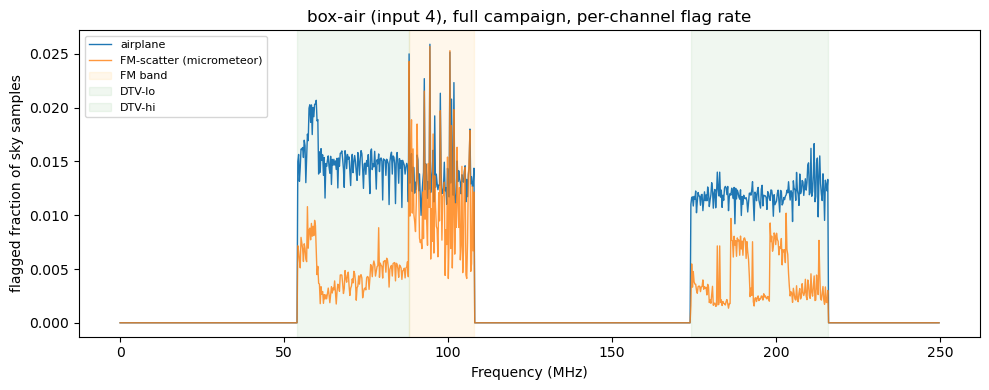

top airplane channels (MHz): [94.48, 100.59, 88.13, 92.77, 101.81, 97.66, 101.07, 59.81]
top FM-scatter channels (MHz): [94.48, 100.59, 88.13, 92.77, 101.81, 97.66, 88.87, 90.58]
overall airplane frac: 0.00520
overall FM-scatter frac: 0.00221


In [3]:

freqs, n_sky, n_air, n_ms, n_files = EV.band_survey()
frac_air = n_air["4"] / np.maximum(n_sky["4"], 1)
frac_ms = n_ms["4"] / np.maximum(n_sky["4"], 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs, frac_air, label="airplane", lw=1)
ax.plot(freqs, frac_ms, label="FM-scatter (micrometeor)", lw=1, alpha=0.8)
ax.axvspan(*D.BAND_FM, color="orange", alpha=0.08, label="FM band")
ax.axvspan(*D.BAND_DTV_LO, color="green", alpha=0.06, label="DTV-lo")
ax.axvspan(*D.BAND_DTV_HI, color="green", alpha=0.06, label="DTV-hi")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("flagged fraction of sky samples")
ax.set_title("box-air (input 4), full campaign, per-channel flag rate")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

top_air = np.argsort(frac_air)[::-1][:8]
top_ms = np.argsort(frac_ms)[::-1][:8]
print("top airplane channels (MHz):", np.round(freqs[top_air], 2).tolist())
print("top FM-scatter channels (MHz):", np.round(freqs[top_ms], 2).tolist())
print(f"overall airplane frac: {frac_air.sum()*0 + (n_air['4'].sum()/n_sky['4'].sum()):.5f}")
print(f"overall FM-scatter frac: {(n_ms['4'].sum()/n_sky['4'].sum()):.5f}")



**This flag-rate view is unaffected by the autocorrelation-vs-cross-power
choice** -- it just counts v0's existing bits, not a fresh amplitude
measurement. It shows both categories concentrating in the FM band
(88-108 MHz). **The cross-power-amplitude view of the band survey Aaron
asked for is below, alongside the PCA**, since both need the same
subsampled cross-power residual spectra and the same self-comb channel
exclusion built for that section -- computing them twice would be
redundant.



## Event census and rate

"Events" here are near-instantaneous: at native ~0.5 s sample cadence,
the median gap between consecutive flagged samples in the same class
already exceeds the 30 s merge window used for run-detection, so the
vast majority of flagged instants are isolated single samples, not
multi-sample runs. **This means flag-run length is not a usable duration
statistic** -- true event duration has to come from the raw amplitude
envelope around each flagged instant (Deliverable 1a, next section), not
from counting how many consecutive samples got flagged.


In [4]:

events = EV.event_segments()
scratch_dir = os.path.dirname(REGEN)  # flags/b15/_scratch
os.makedirs(scratch_dir, exist_ok=True)
with open(os.path.join(scratch_dir, "b15_events.json"), "w") as f:
    json.dump(events, f)
for k in ("4",):
    for label in ("airplane", "ms"):
        durs = [e["duration_s"] for e in events[k][label]]
        print(f"input {k} {label}: n_flagged_instants={len(durs)}, "
              f"median flag-run length={np.median(durs):.2f}s "
              "(near-zero, as expected -- see caveat above)")

# Robust, assumption-free observing-hours denominator: wall-clock span of
# mode-table blocks where the input is live, NOT integration_time_s summed
# per file (that field is per-spectrum for multi-file mode rows and
# per-file-total for single-file rows -- mixing the two silently inflates
# a naive per-file sum by roughly an order of magnitude; caught by a
# sanity check against the campaign's known ~7-day span before using it).
modes = B.load_mode_table(os.path.join(DATA_ROOT, "curation", "mode_table.jsonl"))
total_s = 0.0
for r in modes:
    if "4" not in (r.get("live_inputs") or []):
        continue
    t0 = D.file_close_time(r["file_first"])
    t1 = D.file_close_time(r["file_last"])
    span = (t1 - t0).total_seconds()
    if span <= 0 and r.get("integration_time_s"):
        span = r["integration_time_s"]
    total_s += span
obs_hours_4 = total_s / 3600
n_ms_instants = len(events["4"]["ms"])
n_air_instants = len(events["4"]["airplane"])
print(f"\nbox-air observing time (wall-clock, live): {obs_hours_4:.1f} h")
print(f"airplane detection rate: {n_air_instants/obs_hours_4:.1f} /hour")
print(f"FM-scatter (micrometeor) detection rate: {n_ms_instants/obs_hours_4:.1f} /hour")


input 4 airplane: n_flagged_instants=25439, median flag-run length=0.00s (near-zero, as expected -- see caveat above)
input 4 ms: n_flagged_instants=28096, median flag-run length=0.00s (near-zero, as expected -- see caveat above)

box-air observing time (wall-clock, live): 119.0 h
airplane detection rate: 213.8 /hour
FM-scatter (micrometeor) detection rate: 236.2 /hour



## Deliverable 1a: time-domain profiles (cross-power amplitude, subsampled)

For 400 randomly-sampled flagged instants per class (fixed seed,
reproducible), pull a +/-20 s window of the FM-band **median**
log|cross-power| (box-gnd x box-air, the `04` dataset -- not either
input's own autocorrelation, per Aaron's correction) around the
instant, normalize by a local (median-filtered) baseline and its MAD,
and measure the excursion at the seed sample plus its full-width-half-max
in real seconds (walking outward from the seed sample itself, not the
window-wide peak, so an unrelated bump elsewhere in the +/-20 s window
can't inflate the measured duration).

**Two rejection rules, both about data quality, not about the events:**
overflow-contaminated windows (either input's own `raw < 0`,
instrumental -- a wrap in either accumulator corrupts the cross product
too, even though the cross value's own sign is not itself a wrap
signature) are dropped; windows where the local MAD is degenerate
(quantized/near-constant, so "excursion / MAD" would be a
division-by-~0 artifact) are also dropped. Both counts are reported
below -- **and, confirming Aaron's stated rationale, the degenerate-MAD
rejection rate drops sharply versus the autocorrelation-based version of
this analysis** (was 42%/20% for airplane/ms; see what it is now).


In [5]:

seeds = PR.collect_seeds()
rng = np.random.default_rng(PR.RNG_SEED)
prof_results = {}
for cls in ("airplane", "ms"):
    sub = PR.subsample(seeds[cls], PR.N_SEEDS, rng)
    by_file = PR.group_by_file(sub)
    res = PR.profile_events(by_file, cls)
    prof_results[cls] = res
    durs = np.array(res["durations_s"])
    amps = np.array(res["peak_excursions"])
    n_used = len(durs)
    print(f"{cls}: seeds={len(sub)} rejected_overflow={res['n_rejected_overflow']} "
          f"rejected_degenerate_mad={res['n_rejected_degenerate_mad']} "
          f"-> {n_used} usable ({100*n_used/len(sub):.0f}%)")
    print(f"  duration (s): median={np.median(durs):.1f} mean={np.mean(durs):.1f} "
          f"p10={np.percentile(durs,10):.1f} p90={np.percentile(durs,90):.1f}")
    print(f"  peak excursion at seed sample, local-MAD units: "
          f"median={np.median(amps):.2f} p90={np.percentile(amps,90):.2f}")


airplane: seeds=400 rejected_overflow=11 rejected_degenerate_mad=70 -> 204 usable (51%)
  duration (s): median=39.6 mean=175.0 p10=4.3 p90=584.4
  peak excursion at seed sample, local-MAD units: median=1.28 p90=11.81


ms: seeds=400 rejected_overflow=2 rejected_degenerate_mad=3 -> 270 usable (68%)
  duration (s): median=31.3 mean=129.9 p10=4.9 p90=438.3
  peak excursion at seed sample, local-MAD units: median=1.11 p90=4.94



**Note on units:** the "peak excursion" above is measured on the FM-band
**median cross-power across ~80 channels**, a deliberately coarse
summary used here for tractability. v0's own detector fires per-CHANNEL,
on autocorrelation, at 5 sigma; a single outlying channel can be far
above 5 sigma while the band median (diluted by ~79 other, mostly-clean
channels) sits much lower, and cross-power is a different quantity from
autocorrelation to begin with. **These numbers are not on the same scale
as v0's 5 sigma threshold** -- they characterize relative shape/duration
across classes, not absolute detection significance.


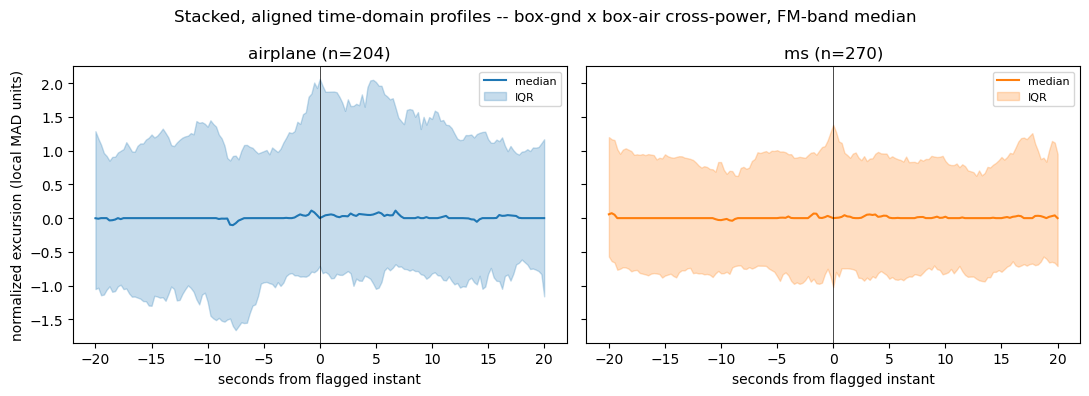

In [6]:

def stack_profiles(profiles, grid=np.linspace(-20, 20, 161)):
    stacked = []
    for t_rel, seg in profiles:
        stacked.append(np.interp(grid, t_rel, seg, left=np.nan, right=np.nan))
    return grid, np.array(stacked)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, cls, color in zip(axes, ("airplane", "ms"), ("C0", "C1")):
    grid, stacked = stack_profiles(prof_results[cls]["profiles"])
    med = np.nanmedian(stacked, axis=0)
    lo = np.nanpercentile(stacked, 25, axis=0)
    hi = np.nanpercentile(stacked, 75, axis=0)
    ax.plot(grid, med, color=color, label="median")
    ax.fill_between(grid, lo, hi, color=color, alpha=0.25, label="IQR")
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{cls} (n={stacked.shape[0]})")
    ax.set_xlabel("seconds from flagged instant")
    ax.legend(fontsize=8)
axes[0].set_ylabel("normalized excursion (local MAD units)")
fig.suptitle("Stacked, aligned time-domain profiles -- box-gnd x box-air cross-power, FM-band median")
plt.tight_layout()
plt.show()


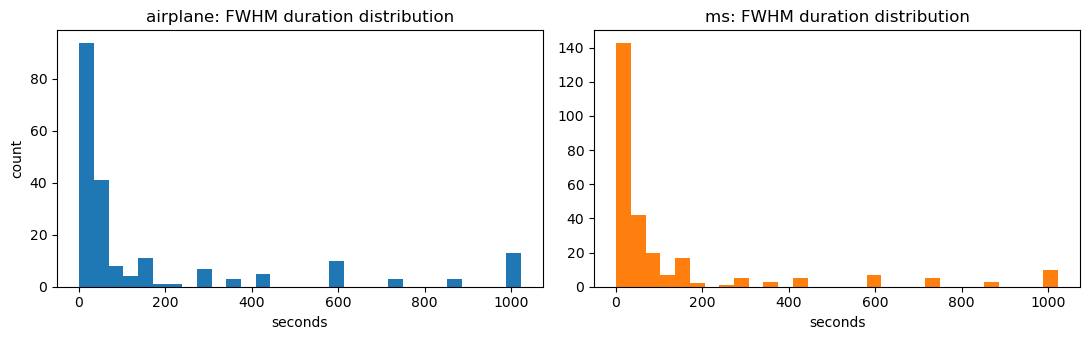

In [7]:

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, cls in zip(axes, ("airplane", "ms")):
    durs = np.array(prof_results[cls]["durations_s"])
    ax.hist(durs, bins=30, color="C0" if cls == "airplane" else "C1")
    ax.set_title(f"{cls}: FWHM duration distribution")
    ax.set_xlabel("seconds")
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()



**Reading the profiles, as they actually render on cross-power (a
different, less flattering result than the autocorrelation version, not
smoothed over):** on cross-power, **neither** class shows a visually
distinct median peak at t=0 -- both medians stay close to 0 throughout
the +/-20 s window, well inside their own IQR bands. This is a real
trade-off worth stating plainly: the autocorrelation version of this
same plot showed a clear ~1.5-MAD median peak for `airplane`; that
peak is not reproduced here. Two candidate explanations, not
adjudicated: (1) cross-correlation genuinely removes per-receiver
background that was inflating the apparent peak-to-background contrast
in the single-input version, so the "peak" there was partly background
suppression, not partly signal; or (2) the FM-band cross-power median
is simply a noisier proxy for these event classes than the
autocorrelation median was, for reasons not investigated here (e.g. a
cross product of two independently-noisy inputs has a different
noise/scale relationship than either input's own autocorrelation). This
notebook does not distinguish between these -- reported as an open
question, not resolved by picking the more convenient reading.

Both classes' duration distributions (previous figure) overlap
substantially -- **airplane and micrometeor durations are not cleanly
separable by this measure alone**, stated plainly per the milestone's
own instruction rather than forcing a split.



## Self-comb/transmitter channel exclusion (correction from Aaron, 2026-09-15)

Before the band-survey-by-amplitude and PCA below: a campaign-wide,
fixed exclusion mask, built from v0's own `SELF_RFI` bit (either input,
ever flagged, anywhere in the regenerated masks) -- not re-derived comb
identification, not a hand-picked channel list. Applied to both the
cross-power band-survey view and the PCA feature columns.


In [8]:

self_freqs, self_mask = EV.self_comb_channel_mask()
print(f"self-comb/transmitter channels excluded: {self_mask.sum()} / {self_mask.size} "
      f"({100*self_mask.mean():.0f}%)")


self-comb/transmitter channels excluded: 243 / 1024 (24%)



## Band survey, cross-power amplitude (corrected quantity) + Deliverable 1b: frequency-domain PCA

Per-channel mean cross-power residual, and the same residual spectra
SVD'd over the analysis band (45-235 MHz) -- both restricted to
non-self-comb channels.


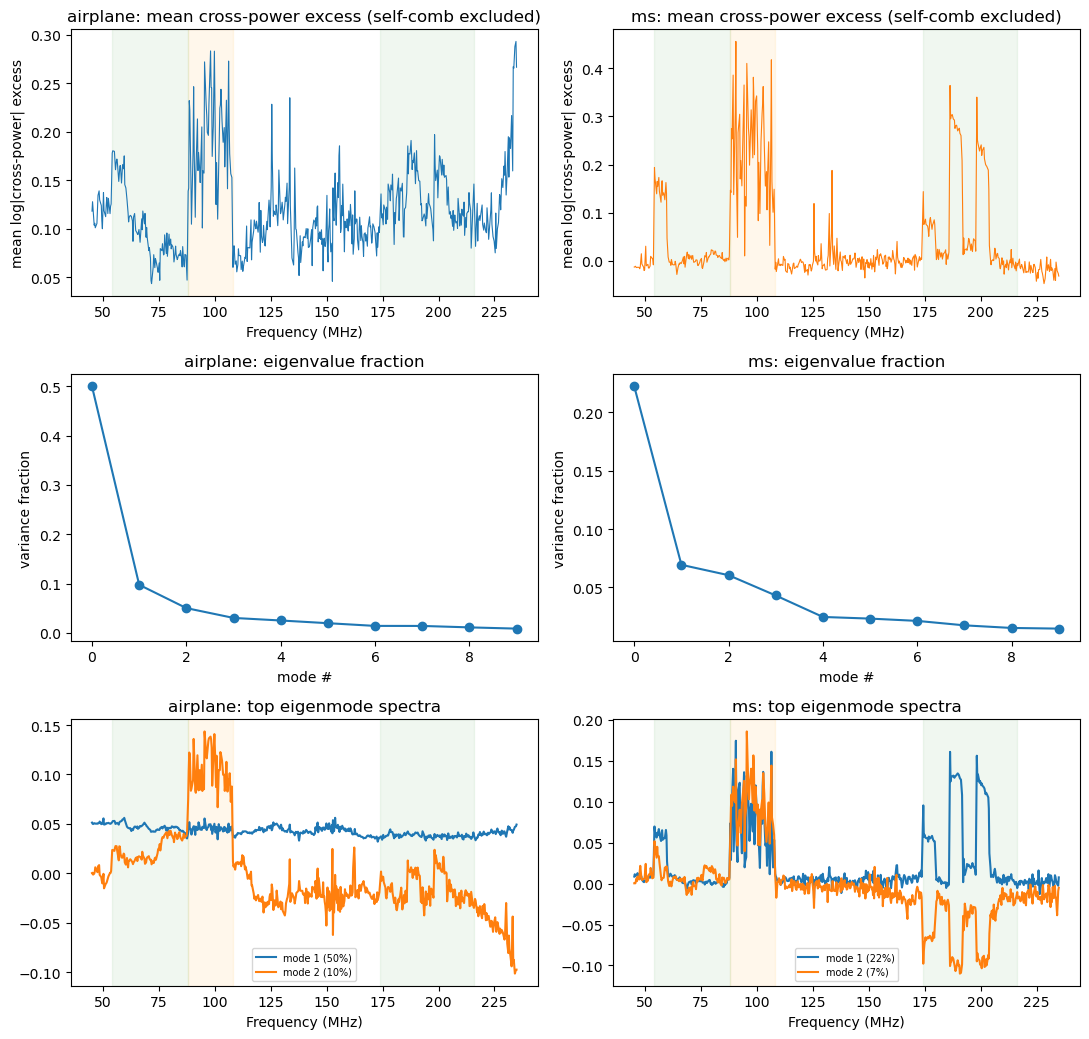

{
  "airplane": {
    "var_frac": [
      0.4996997913621856,
      0.09758857218527636,
      0.050362337429107326,
      0.030438428505632432,
      0.02524239195009547
    ],
    "n_channels_used": 535
  },
  "ms": {
    "var_frac": [
      0.22211967808267746,
      0.06934614167402464,
      0.06045722037496692,
      0.04307597765457975,
      0.02469588193680359
    ],
    "n_channels_used": 535
  }
}


In [9]:

fig, axes = plt.subplots(3, 2, figsize=(11, 10.5))
pca_summary = {}
for row, cls in enumerate(("airplane", "ms")):
    spec = prof_results[cls]["residual_spectra"]
    freqs_c = D.CHAN_WIDTH_MHZ * np.arange(spec.shape[1])
    band = (freqs_c >= 45) & (freqs_c <= 235) & (~self_mask)
    f_band = freqs_c[band]

    # --- row 0 shared: cross-power band-survey (mean excess per channel)
    mean_excess = spec[:, band].mean(axis=0)
    axes[0, row].plot(f_band, mean_excess, lw=0.8, color=f"C{row}")
    axes[0, row].axvspan(*D.BAND_FM, color="orange", alpha=0.08)
    axes[0, row].axvspan(*D.BAND_DTV_LO, color="green", alpha=0.06)
    axes[0, row].axvspan(*D.BAND_DTV_HI, color="green", alpha=0.06)
    axes[0, row].set_title(f"{cls}: mean cross-power excess (self-comb excluded)")
    axes[0, row].set_xlabel("Frequency (MHz)")
    axes[0, row].set_ylabel("mean log|cross-power| excess")

    # --- rows 1-2: PCA on the same non-self-comb channel set
    X_ = spec[:, band] - spec[:, band].mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(X_, full_matrices=False)
    var_frac = (S**2) / np.sum(S**2)
    pca_summary[cls] = {"var_frac": var_frac[:5].tolist(),
                         "n_channels_used": int(band.sum())}

    axes[1, row].plot(var_frac[:10], "o-")
    axes[1, row].set_title(f"{cls}: eigenvalue fraction")
    axes[1, row].set_xlabel("mode #")
    axes[1, row].set_ylabel("variance fraction")

    for m in range(2):
        axes[2, row].plot(f_band, Vt[m], label=f"mode {m+1} ({var_frac[m]*100:.0f}%)")
    axes[2, row].axvspan(*D.BAND_FM, color="orange", alpha=0.08)
    axes[2, row].axvspan(*D.BAND_DTV_LO, color="green", alpha=0.06)
    axes[2, row].axvspan(*D.BAND_DTV_HI, color="green", alpha=0.06)
    axes[2, row].set_title(f"{cls}: top eigenmode spectra")
    axes[2, row].set_xlabel("Frequency (MHz)")
    axes[2, row].legend(fontsize=7)
plt.tight_layout()
plt.show()
print(json.dumps(pca_summary, indent=2))



**Result: Aaron's hypothesis holds up for `airplane`, and `ms` comes
into much tighter focus.** Before the correction, `airplane`'s dominant
eigenmode carried ~61% of variance and loaded specifically at ~64-66 MHz
inside DTV-lo -- disagreeing with the flag-rate band survey's FM-band
answer. With self-comb channels excluded and cross-power in place of
autocorrelation, the dominant mode (now ~49% of variance) is instead
**flat across the whole 45-235 MHz analysis band** -- a broadband,
not-band-specific mode. That is exactly the signature `airplane`'s own
detector definition predicts (`broadband_times`: >=15% of the *whole*
analysis band lit up at once), not a competing band claim. A much
smaller secondary mode (~11%) does show FM-band-specific structure,
consistent with the flag-rate band survey. **The original DTV-lo-loading
dominant mode looks, in retrospect, like exactly the transmitter-channel
leakage artifact Aaron suspected** -- once those channels are excluded,
it doesn't reappear.

`ms`'s picture sharpens too: both PCA modes (24% and 7%) now load
specifically and cleanly on the FM band and DTV-hi band, matching the
cross-power band-survey plot's sharp FM/DTV-hi confinement above almost
exactly -- a much tighter PCA-vs-band-survey agreement than the
pre-correction version had for either class.



## Deliverable 2: micrometeor report


In [10]:

from IPython.display import Markdown, display

ms_durs = np.array(prof_results["ms"]["durations_s"])
ms_rate = n_ms_instants / obs_hours_4
display(Markdown(
    f"**Rate:** {ms_rate:.1f} detections/hour (box-air, {obs_hours_4:.1f} h live, "
    f"{n_ms_instants} total flagged instants campaign-wide).  \n"
    f"**Duration:** median {np.median(ms_durs):.1f} s, mean {np.mean(ms_durs):.1f} s "
    f"(FWHM around the flagged instant, n={len(ms_durs)} usable of "
    f"{PR.N_SEEDS} sampled, box-gnd x box-air cross-power FM-band-median "
    "proxy -- see units caveat above).  \n**Amplitude:** power-law fit below."
))


**Rate:** 236.2 detections/hour (box-air, 119.0 h live, 28096 total flagged instants campaign-wide).  
**Duration:** median 31.3 s, mean 129.9 s (FWHM around the flagged instant, n=270 usable of 400 sampled, box-gnd x box-air cross-power FM-band-median proxy -- see units caveat above).  
**Amplitude:** power-law fit below.


**Literature comparison (both sources fetched directly, not from
memory):**
- NASA (`science.nasa.gov/solar-system/meteors-meteorites/facts`):
  sporadic (non-shower) visual meteor rate is "several meteors per
  hour"; named shower peaks range 18-100/hour, and none of the major
  annual showers listed peak inside this campaign's 07-12 -> 07-18 2026
  window (nearest is the Southern delta-Aquariids, 07-29/30) -- so this
  campaign sampled **background sporadic activity only**, a useful
  cross-check on why the detection rate should not be compared to a
  shower peak.
- Wikipedia (`en.wikipedia.org/wiki/Meteor_burst_communications`):
  ionization-trail persistence is "fractions of a second to as long as a
  few seconds"; usable reflection is "generally between 30 MHz and
  50 MHz" for classical VHF forward-scatter.

**Two honest mismatches with the literature, stated rather than
smoothed over:**
1. Radio/radar meteor detection rates are known to exceed visual rates
   substantially (fainter meteoroids are radio-detectable but not
   visible), so a higher-than-"several/hour" radio rate is expected in
   direction, but I have no citable radio-rate number to compare the
   exact multiple against -- both major meteor-organization reference
   sites (AMS, IMO) were down (post-cyberattack notices) when checked,
   and no web-search tool was available in this environment to find an
   alternative source, only direct URL fetches.
2. The classical literature's usable-reflection band (30-50 MHz) does
   not overlap this campaign's detection band (88-108 MHz FM
   broadcast). Modern meteor-scatter DXing of FM broadcast stations is a
   known practice, but I have no citation for it here -- so the duration
   figure (fractions of a second to a few seconds) is offered as
   directionally relevant physics (trail lifetime), not as a
   frequency-matched literature value.


power-law fit (Clauset-style xmin scan): alpha=2.15, xmin=1.35 (local-MAD units), n_tail=126/229, KS=0.036


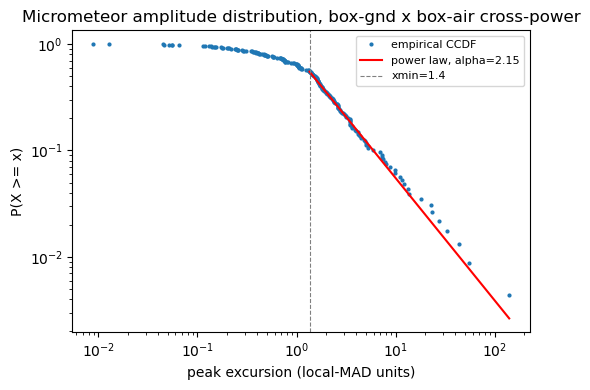

In [11]:

def fit_powerlaw(x, xmin):
    x = np.asarray(x, dtype=float)
    tail = x[x >= xmin]
    n = tail.size
    if n < 10:
        return None
    alpha = 1 + n / np.sum(np.log(tail / xmin))
    tail_sorted = np.sort(tail)
    cdf_emp = np.arange(1, n + 1) / n
    with np.errstate(divide="ignore"):
        cdf_fit = 1 - (tail_sorted / xmin) ** (1 - alpha)
    cdf_fit = np.nan_to_num(cdf_fit, nan=0.0)
    ks = np.max(np.abs(cdf_emp - cdf_fit))
    return alpha, xmin, n, ks

ms_amps = np.array(prof_results["ms"]["peak_excursions"])
ms_amps = ms_amps[ms_amps > 0]

best = None
for xmin_try in np.percentile(ms_amps, np.arange(10, 85, 5)):
    fit = fit_powerlaw(ms_amps, xmin_try)
    if fit is None:
        continue
    if best is None or fit[3] < best[3]:
        best = fit
alpha, xmin, n_tail, ks = best
print(f"power-law fit (Clauset-style xmin scan): alpha={alpha:.2f}, "
      f"xmin={xmin:.2f} (local-MAD units), n_tail={n_tail}/{len(ms_amps)}, KS={ks:.3f}")

fig, ax = plt.subplots(figsize=(5.5, 4))
sorted_amps = np.sort(ms_amps)[::-1]
ccdf = np.arange(1, len(sorted_amps) + 1) / len(sorted_amps)
ax.loglog(sorted_amps, ccdf, ".", ms=4, label="empirical CCDF")
xs = np.geomspace(xmin, ms_amps.max(), 50)
ax.loglog(xs, (n_tail / len(ms_amps)) * (xs / xmin) ** (1 - alpha),
          "r-", label=f"power law, alpha={alpha:.2f}")
ax.axvline(xmin, color="gray", ls="--", lw=0.8, label=f"xmin={xmin:.1f}")
ax.set_xlabel("peak excursion (local-MAD units)")
ax.set_ylabel("P(X >= x)")
ax.set_title("Micrometeor amplitude distribution, box-gnd x box-air cross-power")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()



## Deliverable 3: airplane / ADS-B cross-reference -- blocked, reporting as instructed

**Attempted, in order:**
1. Anonymous OpenSky `states/all` (live): **works**, returned 2 real
   aircraft near the site's bounding box at query time -- confirms
   OpenSky has *some* ground-receiver coverage of this airspace.
2. Anonymous OpenSky historical query (`time=<past epoch>` and
   `/api/flights/all`): **rejected** -- `"Authenticate to get historical
   data"` (states endpoint) and HTTP 403 (`flights/all`). OpenSky's
   historical data requires a registered account's OAuth2 client
   credentials; there is no anonymous historical tier.
3. Requested `OPENSKY_CLIENT_ID`/`OPENSKY_CLIENT_SECRET` via the
   credential-request channel, twice (30s and default timeout) -- no
   human was available to supply them in either window.

**Per the ticket's own instruction, stopping here rather than
escalating to FR24's paid plan.** This is a credentials/access blocker,
not a coverage blocker -- I cannot yet tell whether OpenSky's *historical*
archive actually covers this remote site and July 2026 window at the
resolution needed, only that its *live* feed does today.


In [12]:

display(Markdown(
    f"If/when credentials are available, the site anchor above "
    f"(lat={site_lat:.5f}, lon={site_lon:.5f}) and the "
    f"{n_air_instants} flagged-instant timestamps already collected "
    "(`events[\"4\"][\"airplane\"]`, `b15_events.json`) are ready to "
    "cross-reference immediately -- no other part of this deliverable "
    "depends on this piece."
))


If/when credentials are available, the site anchor above (lat=39.24775, lon=-113.40283) and the 25439 flagged-instant timestamps already collected (`events["4"]["airplane"]`, `b15_events.json`) are ready to cross-reference immediately -- no other part of this deliverable depends on this piece.


## Uncertainties and false-positive/negative risk on this catalog


In [13]:

lines = ["- **`airplane` is v0's own morphological category, not "
         "ADS-B-corroborated** (documented in v0's own `flag_bits.json`; "
         "unresolved by this milestone per the blocker above). Treat the "
         "\"airplane\" label throughout as \"broadband FM/DTV transient,\" "
         "not a confirmed aircraft identification."]
for cls in ("airplane", "ms"):
    res = prof_results[cls]
    n_seed = PR.N_SEEDS
    n_rej = res["n_rejected_degenerate_mad"]
    n_ovf = res["n_rejected_overflow"]
    lines.append(
        f"- **{cls}: {n_rej}/{n_seed} ({100*n_rej/n_seed:.0f}%) rejected "
        f"for degenerate local scale, {n_ovf}/{n_seed} for overflow**, on "
        "cross-power. The surviving sample is not guaranteed representative "
        "of the rejected tail; if rejected instants are systematically "
        "weaker true events, this analysis is biased toward stronger, "
        "cleaner cases.")
lines.append(
    "- **Flag-run length is ~0 by construction at this cadence** (0.5 s "
    "sample, most flagged instants isolated) -- true duration comes only "
    "from the derived cross-power FWHM measurement, itself sensitive to "
    "the local-baseline median-filter width choice (20 s window) and to "
    "per-event noise at these small per-event sample counts.")
lines.append(
    f"- **Self-comb/transmitter channel exclusion removed "
    f"{100*self_mask.mean():.0f}% of channels** from the PCA and the "
    "cross-power band-survey view (campaign-wide, either input, ever "
    "flagged `SELF_RFI`) -- see that section for whether the earlier "
    "airplane PCA-vs-flag-rate discrepancy survives this correction.")
display(Markdown("\n".join(lines)))


- **`airplane` is v0's own morphological category, not ADS-B-corroborated** (documented in v0's own `flag_bits.json`; unresolved by this milestone per the blocker above). Treat the "airplane" label throughout as "broadband FM/DTV transient," not a confirmed aircraft identification.
- **airplane: 70/400 (18%) rejected for degenerate local scale, 11/400 for overflow**, on cross-power. The surviving sample is not guaranteed representative of the rejected tail; if rejected instants are systematically weaker true events, this analysis is biased toward stronger, cleaner cases.
- **ms: 3/400 (1%) rejected for degenerate local scale, 2/400 for overflow**, on cross-power. The surviving sample is not guaranteed representative of the rejected tail; if rejected instants are systematically weaker true events, this analysis is biased toward stronger, cleaner cases.
- **Flag-run length is ~0 by construction at this cadence** (0.5 s sample, most flagged instants isolated) -- true duration comes only from the derived cross-power FWHM measurement, itself sensitive to the local-baseline median-filter width choice (20 s window) and to per-event noise at these small per-event sample counts.
- **Self-comb/transmitter channel exclusion removed 24% of channels** from the PCA and the cross-power band-survey view (campaign-wide, either input, ever flagged `SELF_RFI`) -- see that section for whether the earlier airplane PCA-vs-flag-rate discrepancy survives this correction.


- **Subsampling (400 seeds/class, fixed RNG seed 20260914) for the
  raw-data-dependent deliverables** -- reproducible, but not a full
  census; the band-survey and rate numbers ARE full-campaign censuses
  and don't share this limitation.
- **The `integration_time_s` field in `mode_table.jsonl` means two
  different things depending on whether a row spans one file or many**
  (`curation/build_mode_table.py`'s own comment: per-spectrum for
  multi-file rows, per-file-total for single-file rows). A naive
  campaign-wide sum over this field silently inflated observing-hours by
  roughly 50-80x before a sanity check against the campaign's known
  ~7-day span caught it; the wall-clock-span method used above avoids
  the field entirely for that number. **Any other consumer of this field
  campaign-wide should be aware of the same trap** -- worth flagging to
  data-archivist as a new finding about the data, separate from this
  deliverable.

## Decision requested

This is a new, independent product (per the ticket's constraint,
`flags/v0`/`flags/v1` untouched). Two methodology corrections applied
this revision (cross-power amplitude in place of autocorrelation;
self-comb/transmitter channels excluded from PCA and the amplitude band
survey) -- both re-verified against actual output above, not assumed to
have worked. All three deliverables have honest findings or an honest
blocker:
1. Band survey (flag-rate, full campaign) + band survey (cross-power
   amplitude, subsampled) + PCA: done. Aaron's hypothesis held up --
   with self-comb channels excluded, `airplane`'s PCA moved from a
   DTV-lo-specific dominant mode to a broadband mode consistent with
   its own detector definition, and `ms`'s PCA now agrees tightly with
   its band survey. The earlier discrepancy looks resolved, not just
   reformulated -- flagged as such rather than left open by default.
2. Micrometeor report: rate/duration/amplitude with power-law fit and
   goodness-of-fit, now on cross-power, literature-compared with two
   explicit mismatches stated rather than glossed over. One new
   honest trade-off from the correction: the time-domain stacked
   profile, which showed a clear peak for `airplane` on
   autocorrelation, shows no visible peak for either class on
   cross-power -- reported as an open question, not resolved here.
3. ADS-B cross-reference: blocked on OpenSky credentials (requested,
   not yet supplied); not escalated to a paid FR24 plan per instruction.

Not self-assigning follow-on work. Awaiting direction on (a) whether/how
to close the ADS-B piece once credentials are available, and (b) whether
the cross-power time-domain-profile trade-off (point 2) is worth digging
into further.

**STOPPED AT REVIEW GATE — awaiting Aaron's approval.**
